# Trader Performance vs Market Sentiment Analysis

### Primetrade.ai – Data Science Internship Assignment

**Candidate:** Aman Sharma

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed) influences trader behavior and performance on Hyperliquid.

In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader Dataset Loaded")
print("Sentiment Dataset Loaded")

Trader Dataset Loaded
Sentiment Dataset Loaded


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Better chart style
plt.style.use("ggplot")

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Dataset Overview

In [6]:
print("Trader Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [7]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [10]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 127.5 KB


## 3. Missing Value Analysis

In [11]:
missing_trades = trades.isnull().sum().to_frame(name="Missing Values")
missing_trades

,Missing Values
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [12]:
missing_sentiment = sentiment.isnull().sum().to_frame(name="Missing Values")
missing_sentiment

,Missing Values
timestamp,0
value,0
classification,0
date,0


## 4. Duplicate Records

In [13]:
print("Duplicate rows in Trader Dataset:", trades.duplicated().sum())
print("Duplicate rows in Sentiment Dataset:", sentiment.duplicated().sum())

Duplicate rows in Trader Dataset: 0
Duplicate rows in Sentiment Dataset: 0


## 5. Summary Statistics

In [14]:
trades.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [15]:
sentiment.describe(include="all")

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


## 6. Data Cleaning and Date Alignment

In this section:
- Convert timestamps into datetime format
- Extract daily dates
- Standardize sentiment dates
- Prepare both datasets for merging

In [16]:
print("Trader Columns:")
print(trades.columns)

print("\nSentiment Columns:")
print(sentiment.columns)

Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


## 8. Feature Engineering

Create the key business metrics required for analysis:
- Daily PnL
- Win/Loss
- Daily Trade Count
- Average Trade Size
- Average Leverage
- Long vs Short Ratio

In [18]:
print(trades.columns.tolist())
print(sentiment.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
['timestamp', 'value', 'classification', 'date']


In [19]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])
trades["Date"] = trades["Timestamp IST"].dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [20]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["Date"] = trades["Timestamp IST"].dt.date

In [21]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date']


In [22]:
print(trades[["Date"]].head())
print(sentiment[["Date"]].head())

         Date
0  2024-12-02
1  2024-12-02
2  2024-12-02
3  2024-12-02
4  2024-12-02


KeyError: "None of [Index(['Date'], dtype='str')] are in the [columns]"

Trader Shape: (211224, 16)
Sentiment Shape: (2644, 4)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                         

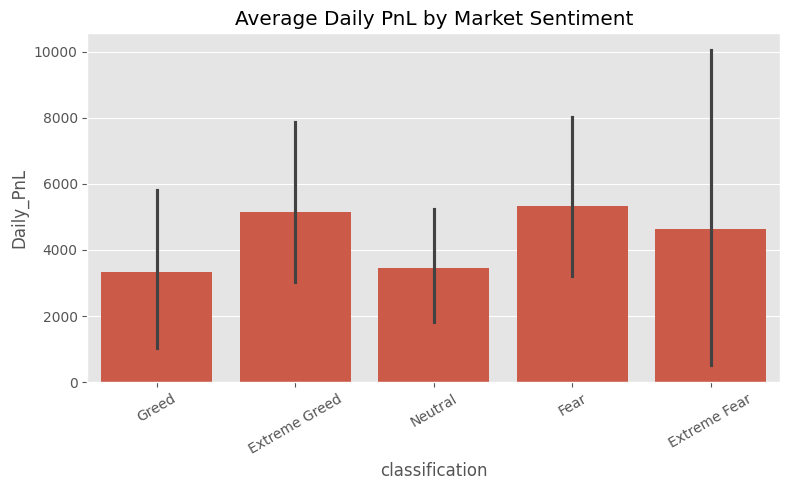

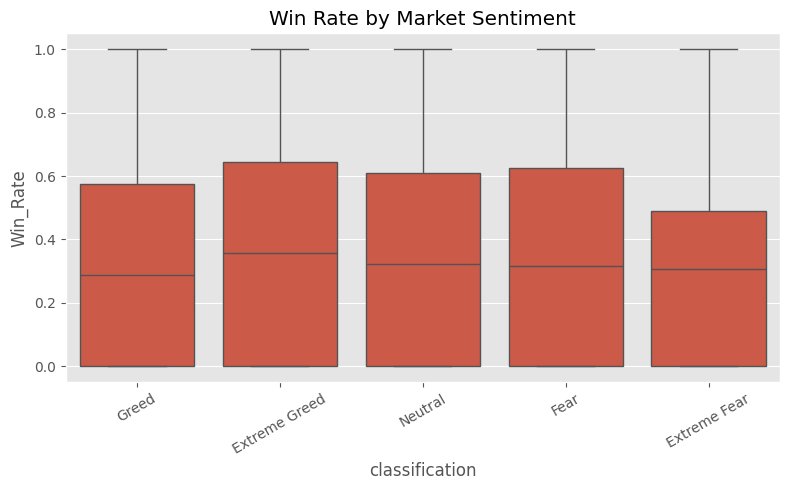

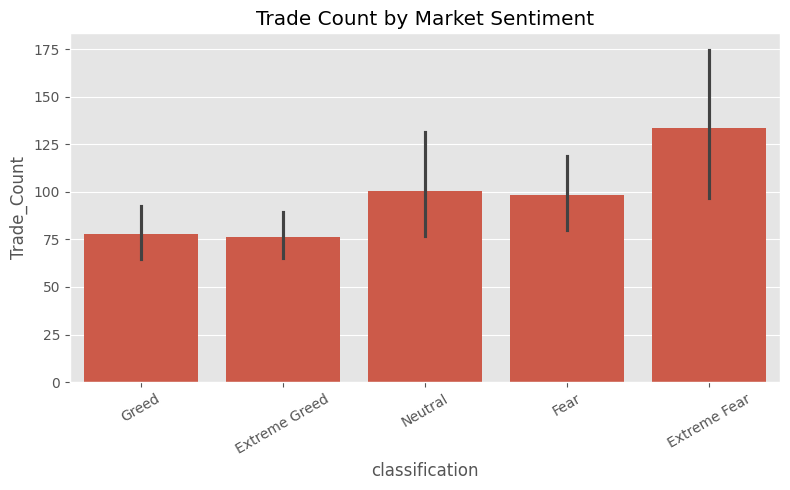

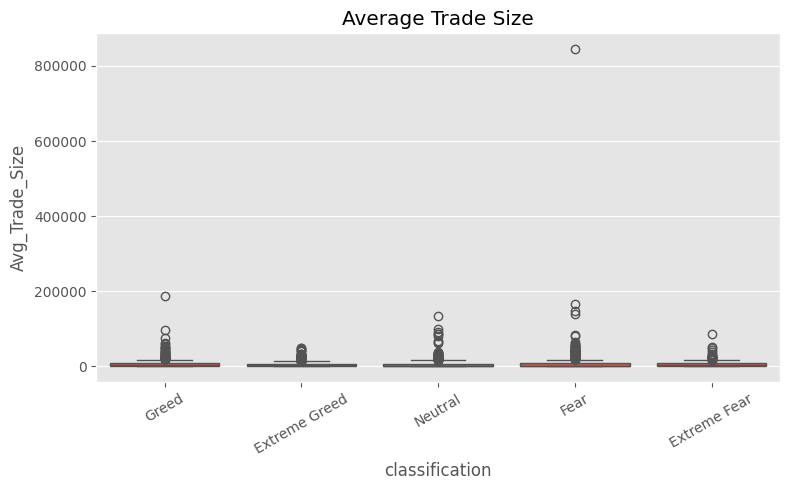

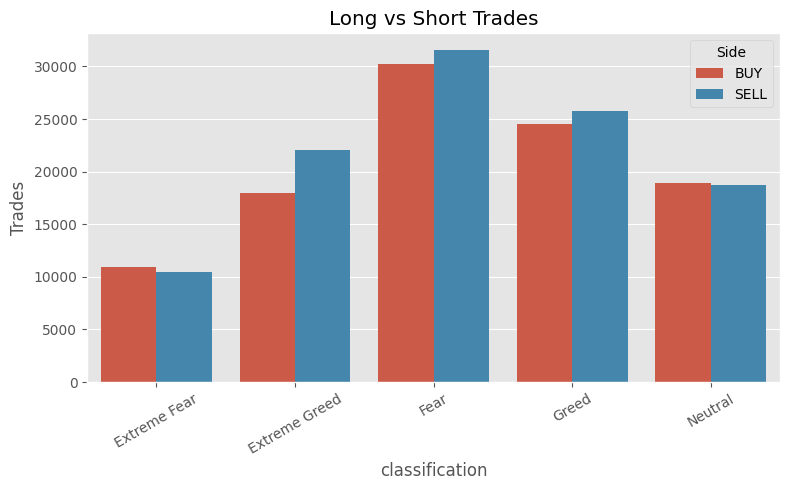

         Date                                     Account classification  \
0  2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891          Greed   
1  2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  Extreme Greed   
2  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   
3  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   
4  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   

    Daily_PnL  Trade_Count  Win_Rate  Avg_Trade_Size  Avg_Leverage  \
0    0.000000            3  0.000000      159.000000      0.091933   
1    0.000000            9  0.000000     5556.203333      2.513867   
2 -205.434737           11  0.363636    10291.213636   -132.574302   
3  -24.632034            2  0.000000     5304.975000  -2440.000000   
4    0.000000            3  0.000000     5116.256667  12124.666667   

  Leverage Segment Frequency Segment Performance Segment  
0              Low        Infrequent               Loser  
1   

In [23]:
# =====================================================
# PRIMETRADE.AI ASSIGNMENT
# Trader Performance vs Market Sentiment
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

# =====================================================
# LOAD DATA
# =====================================================

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

# =====================================================
# DATA CLEANING
# =====================================================

# Trader timestamp
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

trades["Date"] = trades["Timestamp IST"].dt.date

# Sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

# =====================================================
# MERGE
# =====================================================

merged_data = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

print(merged_data.head())

# =====================================================
# FEATURE ENGINEERING
# =====================================================

merged_data["Win"] = (merged_data["Closed PnL"] > 0).astype(int)

# =====================================================
# DAILY METRICS PER ACCOUNT
# =====================================================

metrics = (
    merged_data
    .groupby(["Date","Account","classification"])
    .agg(
        Daily_PnL=("Closed PnL","sum"),
        Trade_Count=("Trade ID","count"),
        Win_Rate=("Win","mean"),
        Avg_Trade_Size=("Size USD","mean"),
        Avg_Leverage=("Start Position","mean")
    )
    .reset_index()
)

print(metrics.head())

# =====================================================
# SENTIMENT ANALYSIS
# =====================================================

summary = (
    metrics
    .groupby("classification")
    .agg(
        Avg_Daily_PnL=("Daily_PnL","mean"),
        Avg_Win_Rate=("Win_Rate","mean"),
        Avg_Trade_Count=("Trade_Count","mean"),
        Avg_Trade_Size=("Avg_Trade_Size","mean"),
        Avg_Leverage=("Avg_Leverage","mean")
    )
)

print(summary)

# =====================================================
# CHART 1
# Average Daily PnL
# =====================================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=metrics,
    x="classification",
    y="Daily_PnL"
)
plt.xticks(rotation=30)
plt.title("Average Daily PnL by Market Sentiment")
plt.tight_layout()
plt.show()

# =====================================================
# CHART 2
# Win Rate
# =====================================================

plt.figure(figsize=(8,5))
sns.boxplot(
    data=metrics,
    x="classification",
    y="Win_Rate"
)
plt.xticks(rotation=30)
plt.title("Win Rate by Market Sentiment")
plt.tight_layout()
plt.show()

# =====================================================
# CHART 3
# Trade Count
# =====================================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=metrics,
    x="classification",
    y="Trade_Count"
)
plt.xticks(rotation=30)
plt.title("Trade Count by Market Sentiment")
plt.tight_layout()
plt.show()

# =====================================================
# CHART 4
# Trade Size
# =====================================================

plt.figure(figsize=(8,5))
sns.boxplot(
    data=metrics,
    x="classification",
    y="Avg_Trade_Size"
)
plt.xticks(rotation=30)
plt.title("Average Trade Size")
plt.tight_layout()
plt.show()

# =====================================================
# LONG / SHORT
# =====================================================

side_summary = (
    merged_data
    .groupby(["classification","Side"])
    .size()
    .reset_index(name="Trades")
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=side_summary,
    x="classification",
    y="Trades",
    hue="Side"
)
plt.xticks(rotation=30)
plt.title("Long vs Short Trades")
plt.tight_layout()
plt.show()

# =====================================================
# TRADER SEGMENTS
# =====================================================

metrics["Leverage Segment"] = np.where(
    metrics["Avg_Leverage"] >= metrics["Avg_Leverage"].median(),
    "High",
    "Low"
)

metrics["Frequency Segment"] = np.where(
    metrics["Trade_Count"] >= metrics["Trade_Count"].median(),
    "Frequent",
    "Infrequent"
)

metrics["Performance Segment"] = np.where(
    metrics["Daily_PnL"] > 0,
    "Winner",
    "Loser"
)

print(metrics.head())

# =====================================================
# SAVE
# =====================================================

metrics.to_csv("daily_trader_metrics.csv", index=False)
merged_data.to_csv("merged_dataset.csv", index=False)

print("Analysis Complete.")